# **ONERA M6 Wing**

The ONERA M6 wing is a swept, semi-span wing with no twist that uses a symmetric airfoil. Widely known to aerodynamicists, the model serves as a classic reference to validate CFD methods for external flow due to its ideal combination of a simple geometry and a complex transonic flow. More information about the ONERA M6 Wing can be found at [NASA’s website](https://turbmodels.larc.nasa.gov/onerawingnumerics_val.html).

The model used here has a normalized root chord of 1 m, resulting in the following geometric parameters:

- Mean Aerodynamic Chord (MAC) = 0.80167 m
- Semi-span = 1.47602 m
- Reference area = 1.15315 $m^2$

<center><img src="https://docs.flexcompute.com/projects/flow360/en/latest/_images/Geometry_Iso1.png"/></center>

The mesh used for this case contains 113K nodes and 663K tetrahedrons, and the flow conditions are:

- Mach Number = 0.84
- Reynolds Number (based on MAC) = 11.72 Million
- Alpha = 3.06°
- Reference Temperature = 297.78 K

## Uploading the mesh file
We upload the mesh file by first importing the Flow360 client and the `OM6wing` class from the examples folder.

In [1]:
# Flow360 imports
import flow360 as fl
from flow360.examples import OM6wing

# We also import and change the log settings to only see ones of level INFO or higher
from flow360.log import log, set_logging_level

log.log_to_file = False
set_logging_level("INFO")

Next we download the mesh file from the server.

In [2]:
OM6wing.get_files()

Then we create a project that will contain our mesh and later our case parameters, and results.

In [3]:
project = fl.Project.from_file(OM6wing.mesh_filename, name="OM6Wing Quick Start")

Output()

Output()

Output()

[11:21:57] INFO: VolumeMesh successfully submitted:                                                                
                   name   = OM6Wing Quick Start                                                                    
                   id     = vm-38d82a2e-2924-46d8-9552-dc7e97c2746a                                                
                   status = uploaded                                                                               
           

We will also create a `volume_mesh` variable to have easier access to all boundaries within the mesh when setting up the simulation.

In [4]:
volume_mesh = project.volume_mesh

Alternatively you can create a project by specyfing the file yourself, for example using:

`project = fl.Project.from_file("my_mesh_file.ugrid", name="Quick Start")`

where `my_mesh_file.ugrid` is the name of the mesh file you want to use. To download the mesh file used here, you can click this [link](https://simcloud-public-1.s3.amazonaws.com/om6/wing_tetra.1.lb8.ugrid). Supported mesh file formats are “*.ugrid”, “*.cgns” and their “*.gz” and “*.bz2” compressions. You can also create a project directly from the geometry file, which will be covered in [Automated Meshing](https://docs.flexcompute.com/projects/flow360/en/latest/quickStart/PythonAPI_AutomatedMeshing/PythonAPI_AutomatedMeshing.html#) and [NREL S809 Airfoil](https://docs.flexcompute.com/projects/flow360/en/latest/quickStart/QuasiAirfoil_AutomatedMeshing/QuasiAirfoil_AutomatedMeshing.html) Quick Start.

## Setting up simulation parmeters

After the mesh is uploaded, we can work on defining relevant parameters used in our simulation using the `SimulationParams` class. We will also utilize `with SI_unit_system` to avoid having to explicitly state units everywhere.

In [5]:
# use SI units
with fl.SI_unit_system:

    # Simulation parameters
    params = fl.SimulationParams(
        # Specify reference geometry values
        reference_geometry=fl.ReferenceGeometry(
            area=1.15315084119231,
            moment_center=[0.0, 0.0, 0.0],
            moment_length=[1.47602, 0.801672958512342, 1.47602],
        ),
        # Assign operating condition in the freestream
        operating_condition=fl.operating_condition_from_mach_reynolds(
            reynolds=14.6e6, mach=0.84, project_length_unit=fl.u.m, alpha=3.06 * fl.u.deg
        ),
        # Set the simulation as steady and provide parameters
        time_stepping=fl.Steady(max_steps=500, CFL=fl.RampCFL(initial=5, final=200, ramp_steps=40)),
        # Create models where boundary conditions and solver settings are specified
        models=[
            # Fluid class contains solver settings, we use defaults here
            fl.Fluid(),
            # Wall, SlipWall and Freestream are boundary conditions
            fl.Wall(name="Wall", surfaces=[volume_mesh["Wing"]]),
            fl.SlipWall(name="SlipWall", surfaces=[volume_mesh["Symmetry"]]),
            fl.Freestream(name="Freestream", surfaces=[volume_mesh["Farfield"]]),
        ],
        # Outputs for post-processing purposes
        outputs=[
            # Surface outputs
            fl.SurfaceOutput(
                output_fields=["primitiveVars", "Cp", "Cf"], surfaces=[volume_mesh["Wing"]]
            ),
            # Volume outputs
            fl.VolumeOutput(output_fields=["primitiveVars", "Mach"]),
        ],
    )

[11:22:27] INFO: using: SI unit system for unit inference.

           INFO: Default value of 288.15 K will be used as temperature.

[11:22:28] INFO: Density and viscosity were calculated based on input data, ThermalState will be automatically     
           created.

Once we have our parameters ready, and our project has been submitted, we can run the case. For more information about configuration parameters, visit [Solver Configuration](https://docs.flexcompute.com/projects/flow360/en/latest/solverConfiguration/solverConfiguration.html#solverconfiguration).

## Running the case

With the mesh ready and `SimulationParams` prepared, we can run the case.

In [6]:
project.run_case(params, name="Case of OM6Wing Quick Start")

You can check the current status of you case by using:

In [7]:
project.case.status

<Flow360Status.PENDING: 'pending'>

## Post processing

We can get a better understanding of the simulation results by post processing them.

In [8]:
case = project.case

# Wait for the case to finish
case.wait()

We will download the results of interest from our simulation.

In [9]:
nonlinear_residuals = case.results.nonlinear_residuals
nonlinear_residuals = nonlinear_residuals.as_dataframe()

cfl = case.results.cfl
cfl = cfl.as_dataframe()

total_forces = case.results.total_forces
total_forces = total_forces.as_dataframe()

Output()

[11:23:43] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpbp9nbg6f/cd4d717b-bfaf-4b17-b1e9-30b58ae938ce.csv

Output()

[11:23:44] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpbp9nbg6f/54e4b513-47f4-4106-a30c-4ac3549e40ce.csv

Output()

[11:23:46] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpbp9nbg6f/84f16ca4-982e-48f9-892d-83a54adccd31.csv

To look at the convergence of our solution, we can plot the non-linear residuals in the following way.

<Axes: xlabel='Pseudo Step', ylabel='residuals'>

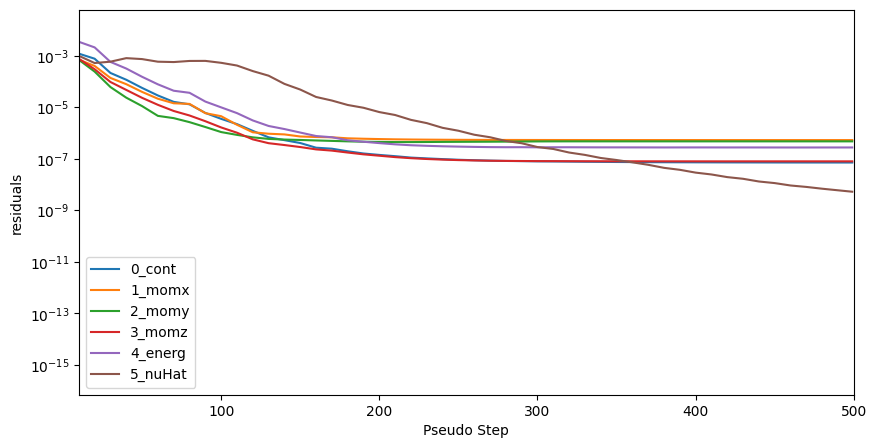

In [10]:
nonlinear_residuals.plot(
    x="pseudo_step",
    y=["0_cont", "1_momx", "2_momy", "3_momz", "4_energ", "5_nuHat"],
    logy=True,
    xlim=(10, 500),
    xlabel="Pseudo Step",
    ylabel="residuals",
    figsize=(10, 5),
)

Another metric worth looking at is how the value of CFL changed for both the Navier-Stokes and Spalart-Allmaras solver.

<Axes: xlabel='pseudo_step'>

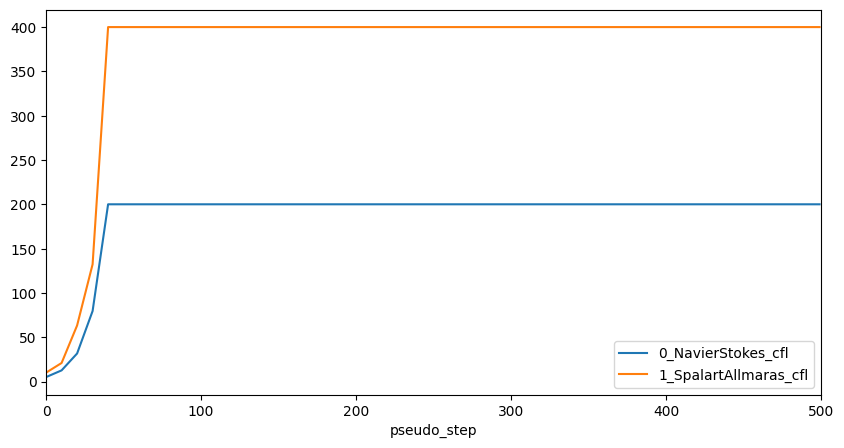

In [11]:
cfl.plot(
    x="pseudo_step",
    y=["0_NavierStokes_cfl", "1_SpalartAllmaras_cfl"],
    xlim=(0, 500),
    figsize=(10, 5),
)

We can also visualize the force and moment coefficients acting on the wing.

<Axes: xlabel='Pseudo Step'>

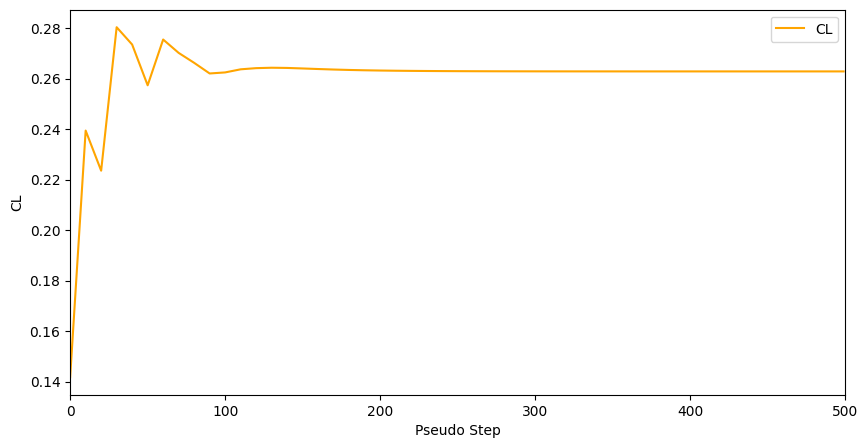

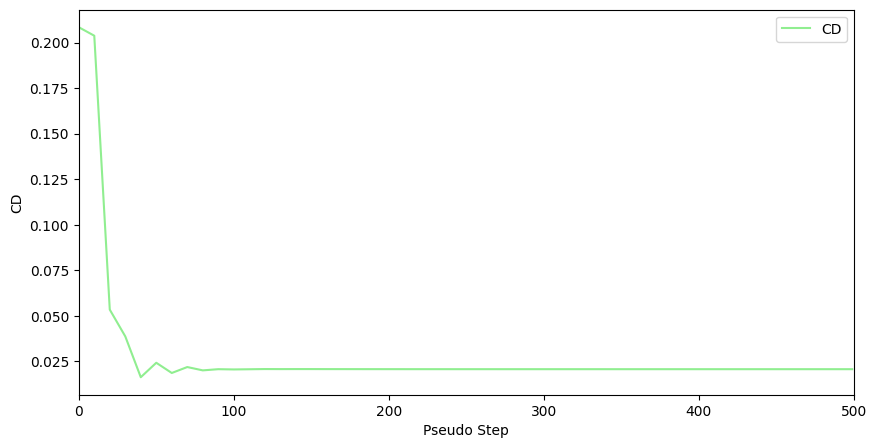

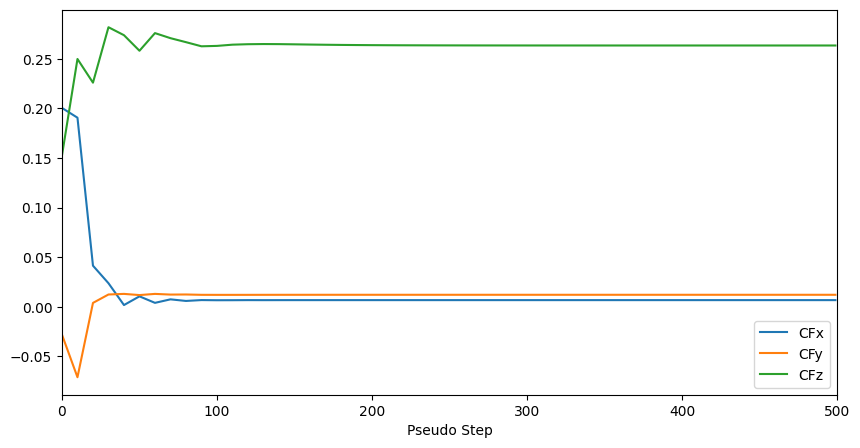

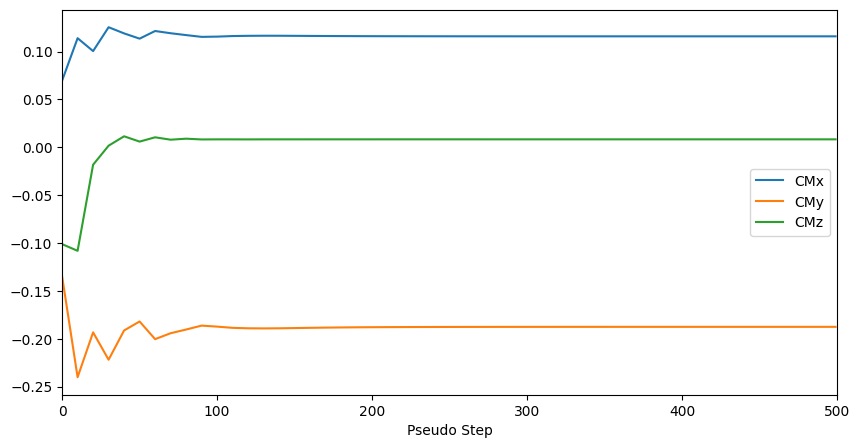

In [12]:
total_forces.plot(
    x="pseudo_step",
    y="CL",
    xlabel="Pseudo Step",
    ylabel="CL",
    xlim=(0, 500),
    figsize=(10, 5),
    style="orange",
)
total_forces.plot(
    x="pseudo_step",
    y="CD",
    xlabel="Pseudo Step",
    ylabel="CD",
    xlim=(0, 500),
    figsize=(10, 5),
    style="lightgreen",
)
total_forces.plot(
    x="pseudo_step",
    y=["CFx", "CFy", "CFz"],
    xlabel="Pseudo Step",
    xlim=(0, 500),
    figsize=(10, 5),
)
total_forces.plot(
    x="pseudo_step",
    y=["CMx", "CMy", "CMz"],
    xlabel="Pseudo Step",
    xlim=(0, 500),
    figsize=(10, 5),
)

For more information about this Quick Start case, visit the [Flow360 documentation](https://docs.flexcompute.com/projects/flow360/en/latest/quickStart/PythonAPI_ONERAM6/PythonAPI_ONERAM6.html#).